# RSO-112: Analyse thermal and stability indicators during Dome louver testing

During the shutdown period (31.1. -14.2) we run multiple versions (different louver configurations) of the BLOCK-T679. Even though we were not on sky and we don’t have the IQ data, we would like to see the inside dome temperature response for different louvers configurations. 

Analyze dome and telescope thermal response during the 6-louver experimental campaigns, focusing on temperature coupling and ventilation behavior in the absence of image-quality (FWHM) indicators.

**Descripcion**

Create a small set of easy-to-interpret temperature indicators that describe how the dome and telescope behave thermally during each louvers configuration.

 

**Expected results:**

New variables:

inside vs outside temperature difference

telescope vs outside temperature difference

temperature gradient across the telescope sensors (111-113)

Table: basic statistics per configuration (average, variation)

Plots: simple box or line plots showing how these indicators change between configurations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState

In [2]:
t_start_period = Time("2026-01-31T00:00:00Z", scale="utc")
t_end_period = Time("2026-02-15T00:00:00Z", scale="utc")

efd_client = makeEfdClient()

In [3]:
# make a list of all topics in the EFD related to MTMount
topics = await efd_client.get_topics()
for topic in topics:
    if 'ESS' in topic:
        print(topic)

lsst.sal.ESS.accelerometer
lsst.sal.ESS.accelerometerPSD
lsst.sal.ESS.ackcmd
lsst.sal.ESS.agcGenset150
lsst.sal.ESS.airFlow
lsst.sal.ESS.airTurbulence
lsst.sal.ESS.command_disable
lsst.sal.ESS.command_enable
lsst.sal.ESS.command_enterControl
lsst.sal.ESS.command_exitControl
lsst.sal.ESS.command_setLogLevel
lsst.sal.ESS.command_standby
lsst.sal.ESS.command_start
lsst.sal.ESS.dewPoint
lsst.sal.ESS.earthquakeBroadBandHighGain
lsst.sal.ESS.earthquakeBroadBandLowGain
lsst.sal.ESS.earthquakeHighBroadBandHighGain
lsst.sal.ESS.earthquakeHighBroadBandLowGain
lsst.sal.ESS.earthquakeLongPeriodHighGain
lsst.sal.ESS.earthquakeLongPeriodLowGain
lsst.sal.ESS.earthquakeUltraLongPeriodHighGain
lsst.sal.ESS.earthquakeVeryLongPeriodHighGain
lsst.sal.ESS.electricFieldStrength
lsst.sal.ESS.hx85a
lsst.sal.ESS.hx85ba
lsst.sal.ESS.lightningStrikeStatus
lsst.sal.ESS.logevent_appliedSettingsMatchStart
lsst.sal.ESS.logevent_authList
lsst.sal.ESS.logevent_configurationApplied
lsst.sal.ESS.logevent_configurationsA

# Queries

In [4]:
def query_setlouvers(start, end):
    df_louvers = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.command_setLouvers",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_louvers

In [5]:
def query_essTemperature(start, end):
    df_esstemperature = getEfdData(
        client=efd_client,
        topic="lsst.sal.ESS.temperature",
        columns=['location', 'private_identity','sensorName', 'temperatureItem0','timestamp'],
        begin=start,
        end=end,
    )

    return df_esstemperature

# Plot functions

In [6]:
def plot_temperature(df_temp, title="Temperature"):

    # Make a copy
    df_temp = df_temp.copy()

    # Convert timestamp to datetime
    df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s')

    # Sort by time
    df_temp = df_temp.sort_values('time')

    # Dictionary to rename sensors in the legend
    sensor_labels = {
        "ESS:111": "Temperature dome inside",
        "ESS:301": "Temperature ess weather station",
        "ESS:113": "Temperature m1m3 inside",
        "ESS:112": "Temperature m2 inside"
    }

    fig, ax = plt.subplots(figsize=(10,6))

    for sensor_id, group in df_temp.groupby('private_identity'):

        label = sensor_labels.get(sensor_id, sensor_id)

        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Force one tick per day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

    # Format showing day and month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_temperature_with_line_louvers(df_temp, df_setlouvers, title="Temperature with Louver Configuration"):

    # Make copies
    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # Convert timestamps
    df_temp['time'] = pd.to_datetime(df_temp['timestamp'], unit='s')
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])

    # Sort data
    df_temp = df_temp.sort_values('time')
    df_setlouvers = df_setlouvers.sort_values('time_stamp')

    # Dictionary to rename sensors
    sensor_labels = {
        "ESS:111": "Temperature dome inside",
        "ESS:301": "Temperature ess weather station",
        "ESS:113": "Temperature m1m3 inside",
        "ESS:112": "Temperature m2 inside"
    }


    fig, ax = plt.subplots(figsize=(10,6))

    # Plot temperatures
    for sensor_id, group in df_temp.groupby('private_identity'):
        label = sensor_labels.get(sensor_id, sensor_id)
        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Vertical lines for configuration changes
    for t in df_setlouvers['time_stamp']:
        ax.axvline(t, linestyle='--', linewidth=1, alpha=0.5)

    # One tick per day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.grid(True)
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [8]:
def plot_temperature_with_louver_shading(df_temp, df_setlouvers, title="Temperature with Louver Configuration"):

    # Copies
    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # Colormap for configuration
    n_confs = df_setlouvers['louvers_conf'].nunique()
    colors = plt.colormaps['tab20'].resampled(n_confs)


    # Convert timestamps
    df_temp['time'] = pd.to_datetime(df_temp['time'], utc=True)
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True)
    df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True)

    # Remove timezone
    df_temp['time'] = df_temp['time'].dt.tz_convert(None)
    df_setlouvers['time_stamp'] = df_setlouvers['time_stamp'].dt.tz_convert(None)
    df_setlouvers['time_end'] = df_setlouvers['time_end'].dt.tz_convert(None)

    # Dictionary to rename sensors
    sensor_labels = {
        "ESS:111": "Temperature dome inside",
        "ESS:301": "Temperature ess weather station",
        "ESS:113": "Temperature m1m3 inside",
        "ESS:112": "Temperature m2 inside"
    }


    fig, ax = plt.subplots(figsize=(10,6))

    # Plot temperature sensors
    for sensor_id, group in df_temp.groupby('private_identity'):
        label = sensor_labels.get(sensor_id, sensor_id)
        ax.plot(group['time'], group['temperatureItem0'], label=label)

    # Shading by configuration
    for _, row in df_setlouvers.iterrows():
        start = row['time_stamp']
        end = row['time_end']
        conf_num = int(row['louvers_conf']) - 1
        ax.axvspan(start, end, color=colors(conf_num), alpha=0.15)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_temperature_with_louvers(df_temp, df_setlouvers):

    df_temp = df_temp.copy()
    df_setlouvers = df_setlouvers.copy()

    # --- Fix timezone issues ---
    df_temp['time'] = pd.to_datetime(df_temp['time'], utc=True).dt.tz_convert(None)
    df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True).dt.tz_convert(None)
    df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True).dt.tz_convert(None)

    # Number of unique configuration
    conf_ids = sorted(df_setlouvers['louvers_conf'].unique())
    n_confs = len(conf_ids)

    colors = plt.get_cmap('tab20', n_confs)

    position_cols = df_setlouvers.filter(regex=r'^position').columns
    position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

    def build_conf_label(row):
        config = row[position_cols]
        non_zero = config[config != 0]

        if len(non_zero) == 0:
            return f"Configuration {row['louvers_conf']}: all closed"

        lines = [f"Configuration {row['louvers_conf']}:"]
        for col, val in non_zero.items():
            lines.append(f"{col}: {int(val)}")

        return "\n".join(lines)

    df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

    sensor_labels = {
        "ESS:111": "Temperature dome inside",
        "ESS:301": "Temperature ess weather station",
        "ESS:113": "Temperature m1m3 inside",
        "ESS:112": "Temperature m2 inside"
    }

    for conf_num in conf_ids:

        fig, ax = plt.subplots(figsize=(10,6))

        for sensor_id, group in df_temp.groupby('private_identity'):
            label = sensor_labels.get(sensor_id, sensor_id)
            ax.plot(group['time'], group['temperatureItem0'], label=label)

        conf_df = df_setlouvers[df_setlouvers['louvers_conf'] == conf_num]

        for _, row in conf_df.iterrows():
            start = row['time_stamp']
            end = row['time_end']
            label = row['conf_label']
            ax.axvspan(start, end, color=colors(int(conf_num)-1), alpha=0.3, label=label)

        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

        plt.xlabel("Day")
        plt.ylabel("Temperature (°C)")
        plt.title(f"Temperature - Louver Configuration {conf_num}")

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02,1), loc='upper left')

        ax.grid(True)
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

## Function for analysis and stadistic plots

In [10]:
def compute_louvers_stats(df_setlouvers, df_temp_inandout):
    """
    Calcula estadísticas de temperatura por configuración de louvers y sensor.

    Parámetros:
    -----------
    df_setlouvers : pd.DataFrame
        DataFrame con las columnas ['time_stamp', 'time_end', 'louvers_conf', 'conf_label']
    df_temp_inandout : pd.DataFrame
        DataFrame con las columnas ['time', 'private_identity', 'temperatureItem0']

    Retorna:
    --------
    pd.DataFrame
        DataFrame con estadísticas por sensor y configuración de louvers.
    """
    results = []

    for _, conf in df_setlouvers.iterrows():
        start = conf['time_stamp']
        end = conf['time_end']
        conf_id = conf['louvers_conf']
        conf_label = conf['conf_label']

        # Datos dentro del intervalo
        subset = df_temp_inandout[(df_temp_inandout['time'] >= start) & (df_temp_inandout['time'] <= end)]

        duration = (end - start).total_seconds() / 60  # minutos

        for sensor, group in subset.groupby('private_identity'):
            temp = group['temperatureItem0']

            if len(temp) < 2:
                continue

            gradient = (temp.iloc[-1] - temp.iloc[0]) / duration

            results.append({
                "louvers_conf": conf_id,
                "conf_label": conf_label,
                "sensor": sensor,
                "duration_min": duration,
                "mean_temp": temp.mean(),
                "std_temp": temp.std(),
                "min_temp": temp.min(),
                "max_temp": temp.max(),
                "temp_range": temp.max() - temp.min(),
                "gradient_deg_per_min": gradient
            })

    df_stats = pd.DataFrame(results)
    return df_stats

In [11]:
def plot_mean_temp_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar chart showing the average temperature per louver setting
    for each sensor, including a legend explaining the meaning of each setting.

    Parámetros:
    -----------
    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'mean_temp', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']
    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="mean_temp",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Mean Temperature (°C)")
    plt.title("Mean Temperature per Louver Configuration")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [12]:
def plot_temp_stability_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar chart showing the standard deviation of the temperature
    by louver setting for each sensor. Lower std → more stable thermal behavior.


    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'std_temp', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']

    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="std_temp",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Standard Deviation (°C)")
    plt.title("Temperature Stability per Louver Configuration")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [13]:
def plot_temp_gradient_per_louver(df_stats, df_setlouvers):
    """
    Generate a bar graph showing the temperature gradient per louver setting
    for each sensor. Positive values → temperature increase, negative values → cooling.

    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', 'gradient_deg_per_min', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']

    """
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=df_stats,
        x="louvers_conf",
        y="gradient_deg_per_min",
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel("Temperature Gradient (°C/min)")
    plt.title("Temperature Gradient per Louver Configuration")
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linestyle='--')
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [14]:
def plot_temp_distribution_per_louver(df_stats, df_setlouvers, value_col="mean_temp"):
    """
    Generate a boxplot of the temperature distribution by louver configuration
    for each sensor, showing variability and outliers.

    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']
    value_col : str, opcional
        Columna de df_stats a graficar (por defecto 'mean_temp')
    """
    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df_stats,
        x="louvers_conf",
        y=value_col,
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel(f"{value_col.replace('_',' ').title()} (°C)")
    plt.title(f"Temperature Distribution per Louver Configuration ({value_col})")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

In [15]:
def plot_temp_stability_distribution(df_stats, df_setlouvers, value_col="std_temp"):
    """
    Generate a boxplot of the standard deviation temperature distribution
    by louver configuration for each sensor, showing thermal stability.


    df_stats : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'sensor', ...]
    df_setlouvers : pd.DataFrame
        DataFrame with columnas ['louvers_conf', 'conf_label']
    value_col : str, opcional
        Columna de df_stats a graficar (por defecto 'std_temp')

    """
    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df_stats,
        x="louvers_conf",
        y=value_col,
        hue="sensor"
    )

    plt.xlabel("Louver Configuration")
    plt.ylabel(f"{value_col.replace('_',' ').title()} (°C)")
    plt.title(f"Temperature Stability Distribution per Configuration ({value_col})")
    plt.xticks(rotation=45)
    plt.grid(True)

    conf_map = (
        df_setlouvers[['louvers_conf','conf_label']]
        .drop_duplicates()
        .sort_values('louvers_conf')
    )

    text = "\n".join(
        f"{row.louvers_conf} → {row.conf_label}"
        for _, row in conf_map.iterrows()
    )

    plt.gcf().text(
        1.02,
        0.5,
        "Configuration meaning:\n\n" + text,
        fontsize=9,
        va="center"
    )

    plt.tight_layout()
    plt.show()

# Configuration of louvers

In [16]:
df_setlouvers = query_setlouvers(t_start_period, t_end_period)

In [17]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,position8,position9,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp
2026-01-31 03:29:22.218386+00:00,0,0,0,30,30,0,0,0,0,0,...,0,0,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09
2026-01-31 04:31:45.671592+00:00,0,0,0,60,60,0,0,0,0,0,...,0,0,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09
2026-01-31 05:33:17.384032+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09
2026-02-01 03:15:59.271655+00:00,0,0,0,100,100,0,0,0,0,0,...,0,0,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09
2026-02-01 07:24:23.956772+00:00,0,0,0,0,0,0,0,0,0,0,...,0,0,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09


In [18]:
# Copy current index into a new column before any merge
df_setlouvers['time_stamp'] = df_setlouvers.index

In [19]:
# Select all columns that start with "position"
position_cols = df_setlouvers.filter(regex=r'^position').columns

# Sort columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position', '')))

# Compute unique combinations
combination_counts = (
    df_setlouvers[position_cols]
    .value_counts()
    .reset_index(name='count')
)

# Create configuration ID (1 to N)
combination_counts['louvers_conf'] = range(1, len(combination_counts) + 1)

# Merge configuration ID back into original dataframe
df_setlouvers = df_setlouvers.merge(
    combination_counts[position_cols + ['louvers_conf']],
    on=position_cols,
    how='left'
)

print(f"Number of unique configurations detected: {len(combination_counts)}\n")

# Print configurations showing only non-zero positions
for _, row in combination_counts.iterrows():
    
    conf_id = row['louvers_conf']
    count = row['count']
    
    print(f"Configuration {conf_id} (appears {count} times):")
    
    # Extract position values
    config = row[position_cols]
    
    # Keep only non-zero values
    non_zero = config[config != 0]
    
    if len(non_zero) == 0:
        print("  All positions are 0")
    else:
        for col, val in non_zero.items():
            print(f"  {col}: {val}")
    
    print("-" * 40)

Number of unique configurations detected: 15

Configuration 1 (appears 17 times):
  position2: 100
  position11: 100
  position12: 100
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 2 (appears 14 times):
  position2: 10
  position11: 10
  position12: 10
  position20: 10
  position21: 10
  position29: 10
----------------------------------------
Configuration 3 (appears 5 times):
  position2: 50
  position11: 50
  position12: 50
  position20: 50
  position21: 50
  position29: 50
----------------------------------------
Configuration 4 (appears 4 times):
  position11: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 5 (appears 4 times):
  position2: 100
  position11: 100
  position12: 100
----------------------------------------
Configuration 6 (appears 4 times):
  position20: 100
  position21: 100
  position29: 100
----------------------------------------
Configuration 7 (appears 2

15 combinations have been made, varying the opening of the louvers: 2, 11, 12, 20, 21, and 29.

In [20]:
df_setlouvers.head()

,position0,position1,position10,position11,position12,position13,position14,position15,position16,position17,...,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,time_stamp,louvers_conf
0,0,0,0,30,30,0,0,0,0,0,...,1.769830e+09,Script:100102,1.769830e+09,37088,0,0afdb49a,1512418370,1.769830e+09,2026-01-31 03:29:22.218386+00:00,11
1,0,0,0,60,60,0,0,0,0,0,...,1.769834e+09,Script:100103,1.769834e+09,37176,0,0afdb49a,1512418370,1.769834e+09,2026-01-31 04:31:45.671592+00:00,13
2,0,0,0,100,100,0,0,0,0,0,...,1.769838e+09,Script:100104,1.769838e+09,37261,0,0afdb49a,1512418370,1.769838e+09,2026-01-31 05:33:17.384032+00:00,1
3,0,0,0,100,100,0,0,0,0,0,...,1.769916e+09,Script:100159,1.769916e+09,60487,0,0afdb49a,1512418370,1.769916e+09,2026-02-01 03:15:59.271655+00:00,1
4,0,0,0,0,0,0,0,0,0,0,...,1.769931e+09,Script:100172,1.769931e+09,65874,0,0afdb49a,1512418370,1.769931e+09,2026-02-01 07:24:23.956772+00:00,14


# ESS Temperature

In [21]:
df_esstemperature = query_essTemperature(t_start_period, t_end_period)

In [22]:
df_esstemperature.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.024693+00:00,AT azimuth axis,ESS:201,AuxTel-ESS02,17.780001,1.769818e+09
2026-01-31 00:00:00.292090+00:00,"Unused, Tangent link A1, Tangent link A2, Tang...",ESS:106,M2-ESS01,NaN,1.769818e+09
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.220000,1.769818e+09
2026-01-31 00:00:00.578594+00:00,M1M3; RPi with sticker 4,ESS:113,M1M3-ESS03,14.670000,1.769818e+09
2026-01-31 00:00:00.586227+00:00,M2; RPi with sticker 1,ESS:112,M2-ESS02,14.930000,1.769818e+09


## Inside vs outside temperature difference

ess_weather_station_sal_index = 301
m1m3_inside_cell_sal_index = 113
dome_inside_sal_index = 111


In [23]:
# Keep only the ESS identities with 111, 112 and 113
df_temp_inandout = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:301'])
].copy()

In [24]:
df_temp_inandout.head()

,location,private_identity,sensorName,temperatureItem0,timestamp
2026-01-31 00:00:00.578568+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.22,1.769818e+09
2026-01-31 00:00:01.606246+00:00,Weather tower,ESS:301,Weather tower air temperature,14.15,1.769818e+09
2026-01-31 00:00:02.011495+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.21,1.769818e+09
2026-01-31 00:00:03.365202+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.22,1.769818e+09
2026-01-31 00:00:04.604516+00:00,Camera inlet plane; RPi with sticker 3,ESS:111,Camera-ESS01,15.17,1.769818e+09


### Plots of telescope sensors (111 and 301)

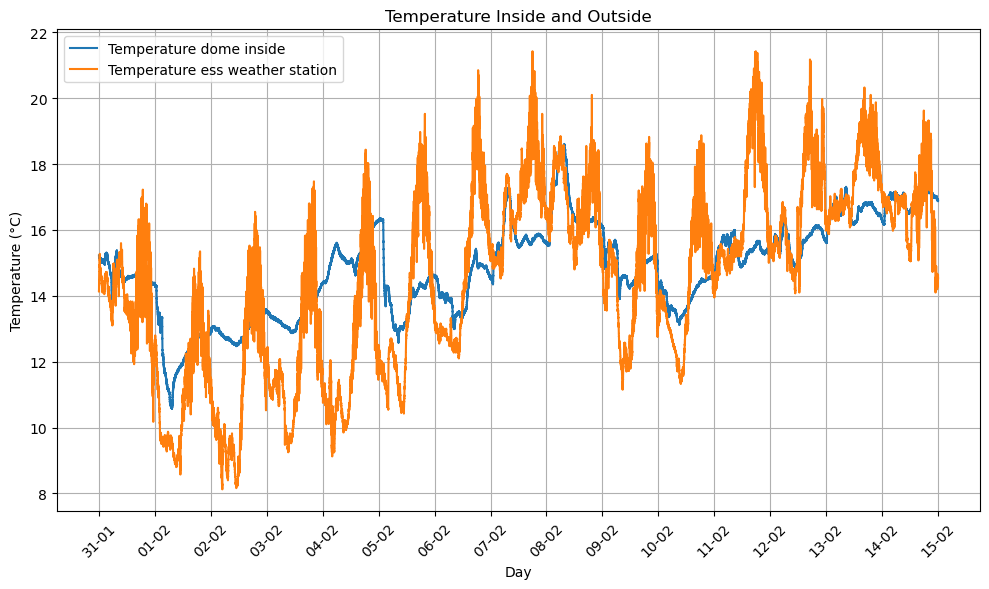

In [25]:
plot_temperature(df_temp_inandout, title="Temperature Inside and Outside")

### Cross with the louver settings

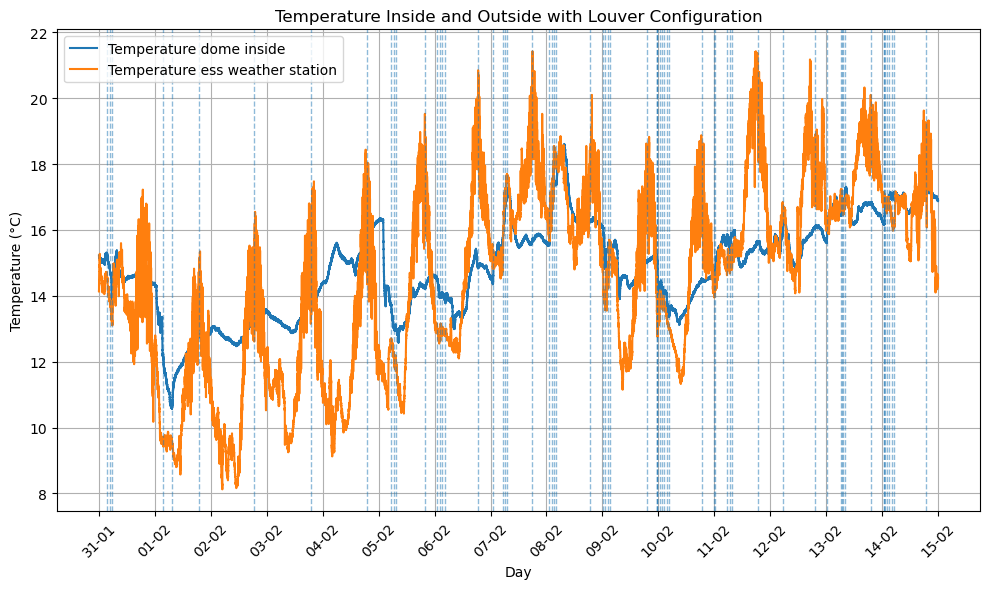

In [26]:
plot_temperature_with_line_louvers(
    df_temp_inandout,
    df_setlouvers,
    "Temperature Inside and Outside with Louver Configuration"
)

In [27]:
# Add in df_setlouvers configuration the end of each configuration
df_setlouvers['time_end'] = df_setlouvers['time_stamp'].shift(-1)
df_temp_inandout['time'] = pd.to_datetime(df_temp_inandout['timestamp'], unit='s')
max_time = df_temp_inandout['time'].max()
df_setlouvers['time_end'] = df_setlouvers['time_end'].fillna(max_time)

In [28]:
# Column positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Function to labels
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]

    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"

    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

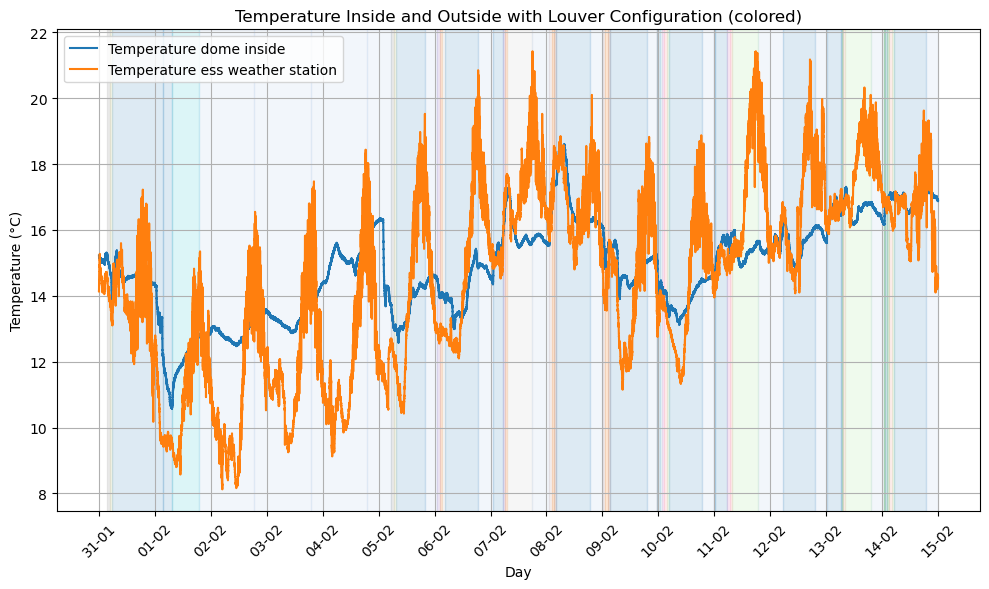

In [29]:
plot_temperature_with_louver_shading(
    df_temp_inandout,
    df_setlouvers,
    "Temperature Inside and Outside with Louver Configuration (colored)"
)

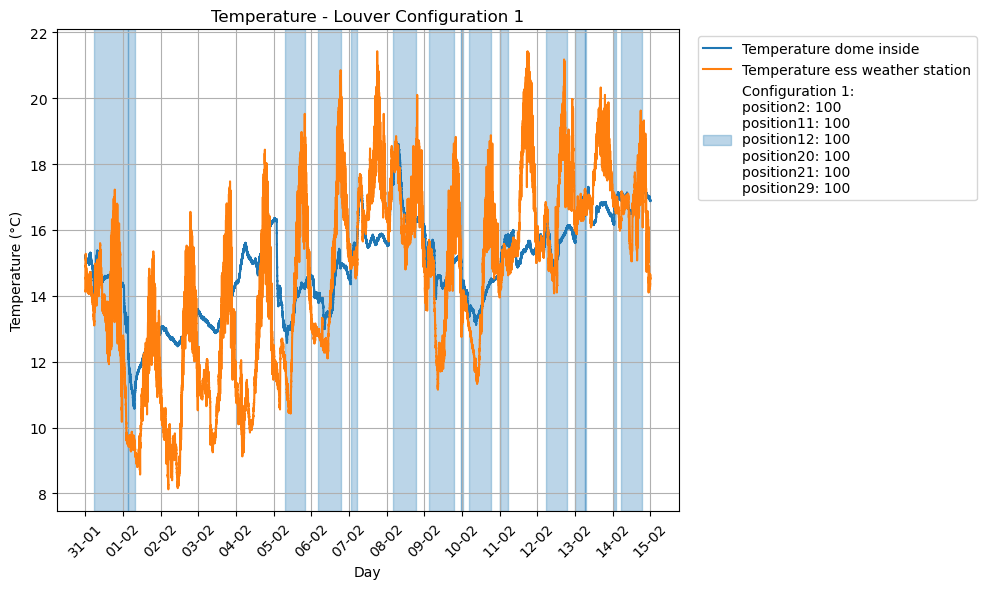

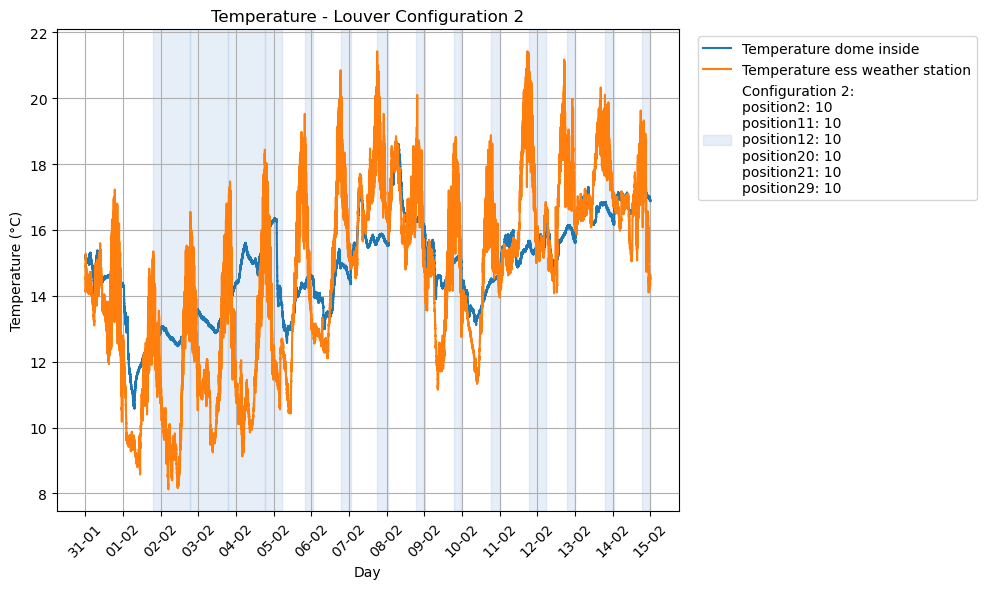

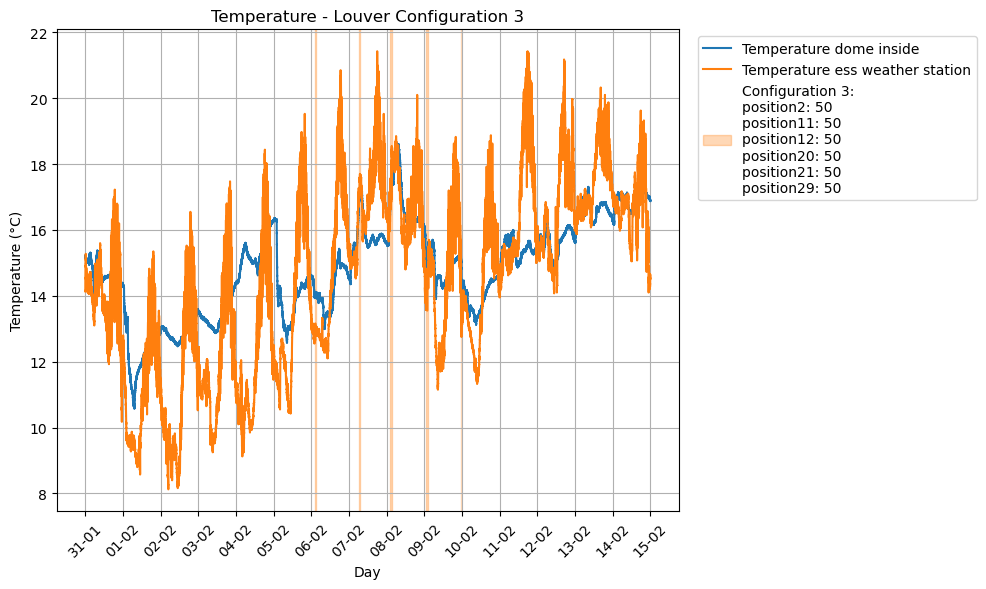

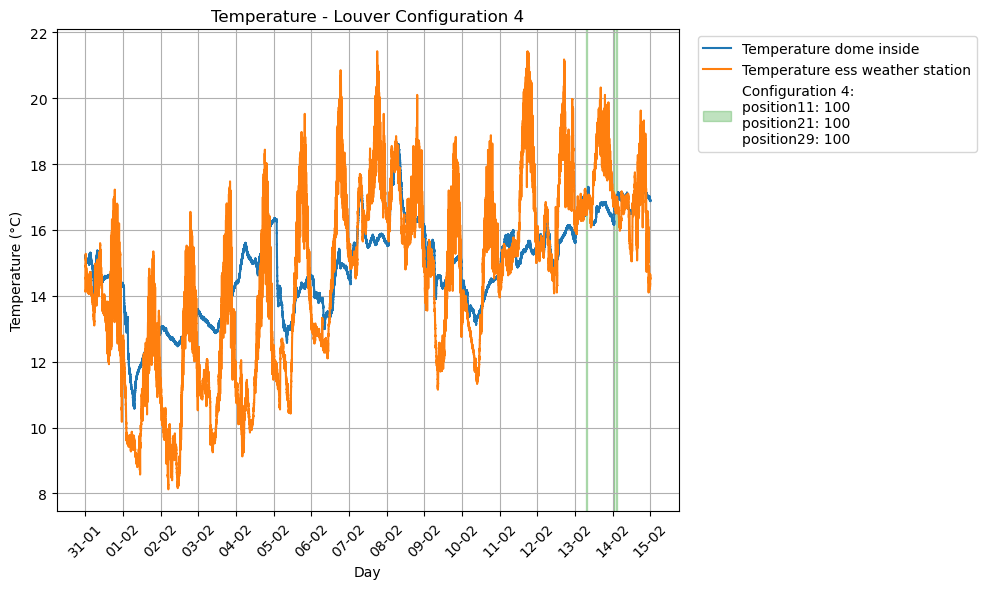

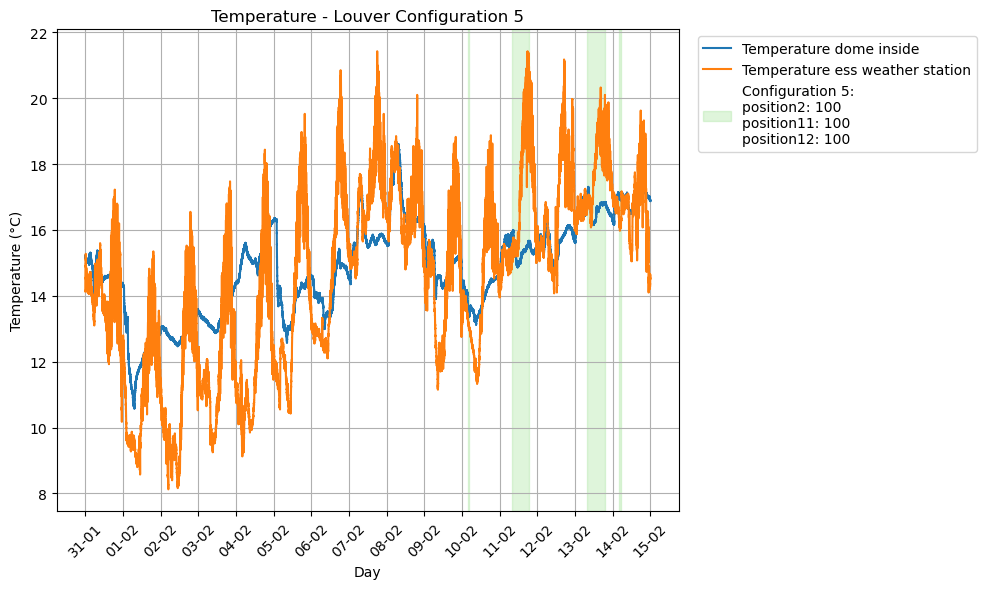

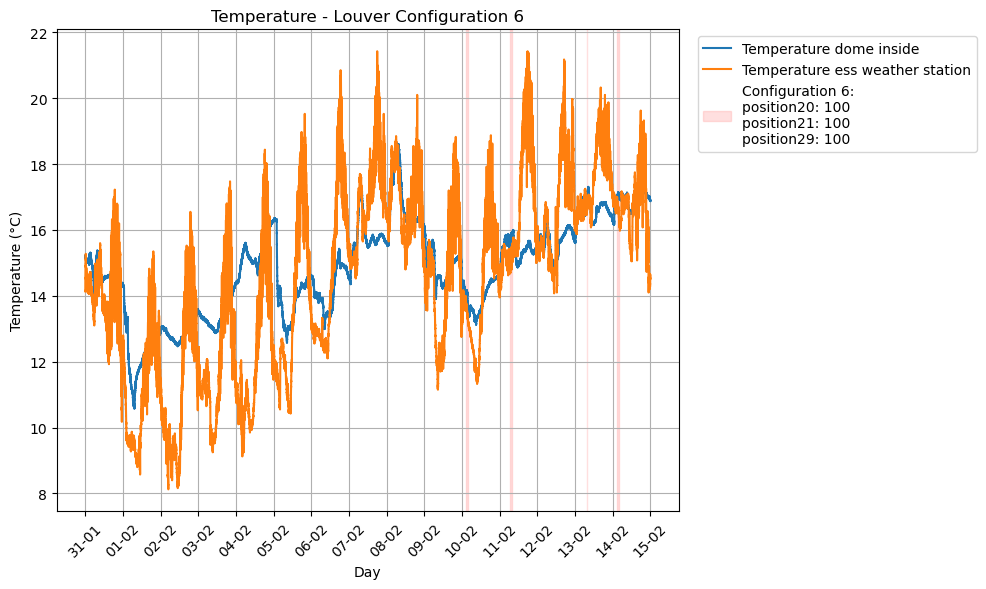

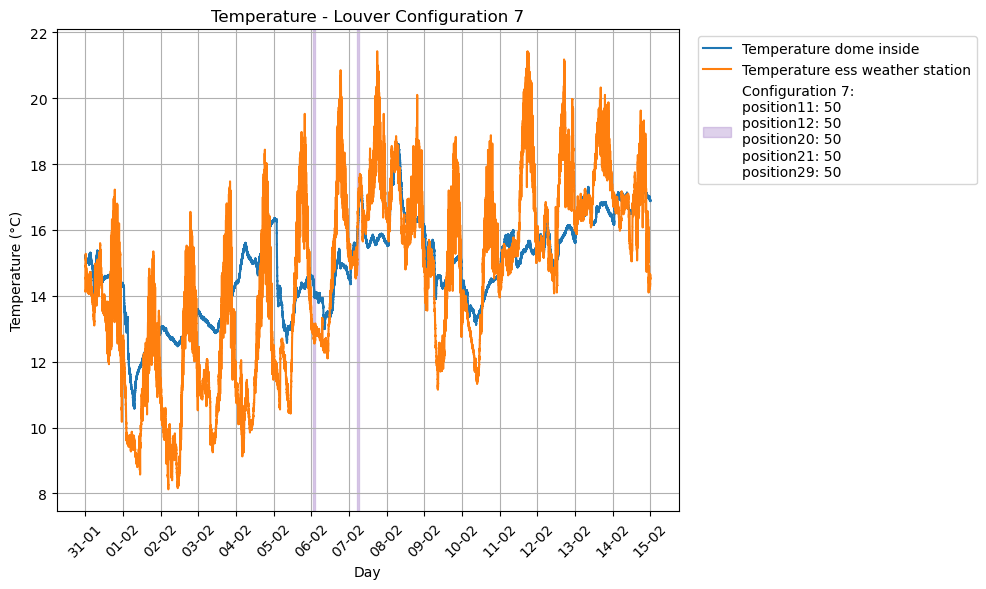

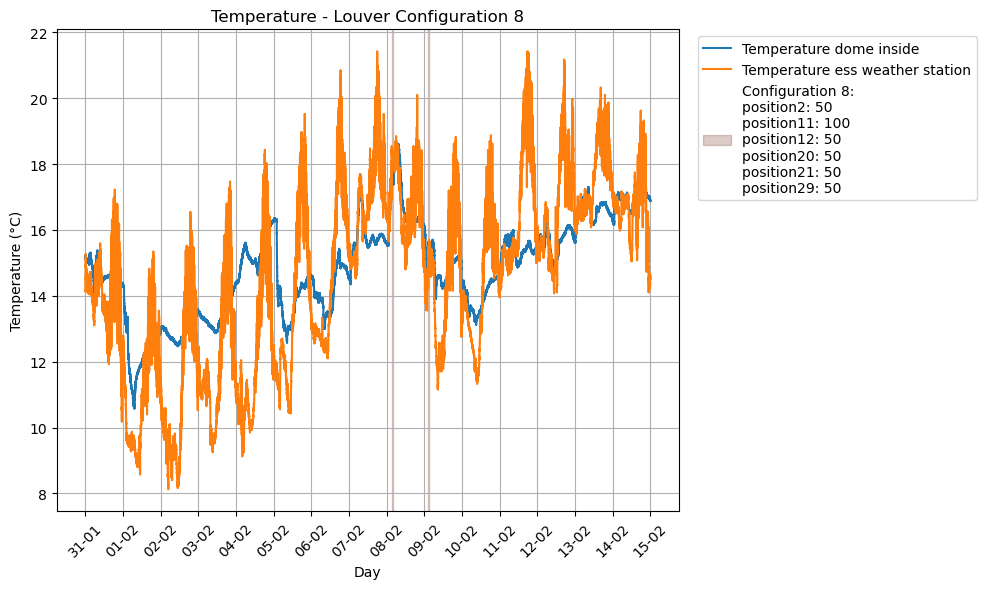

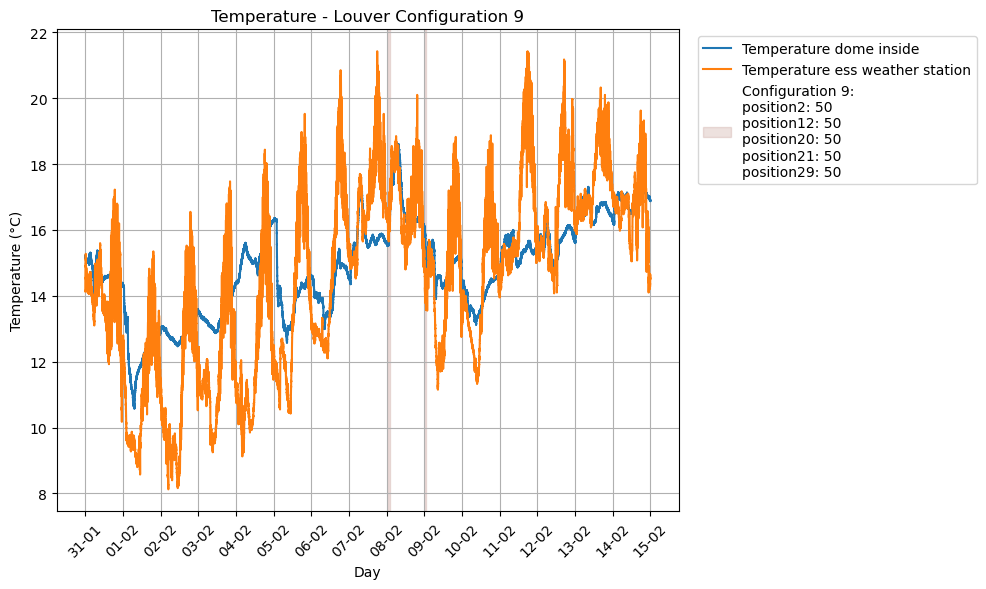

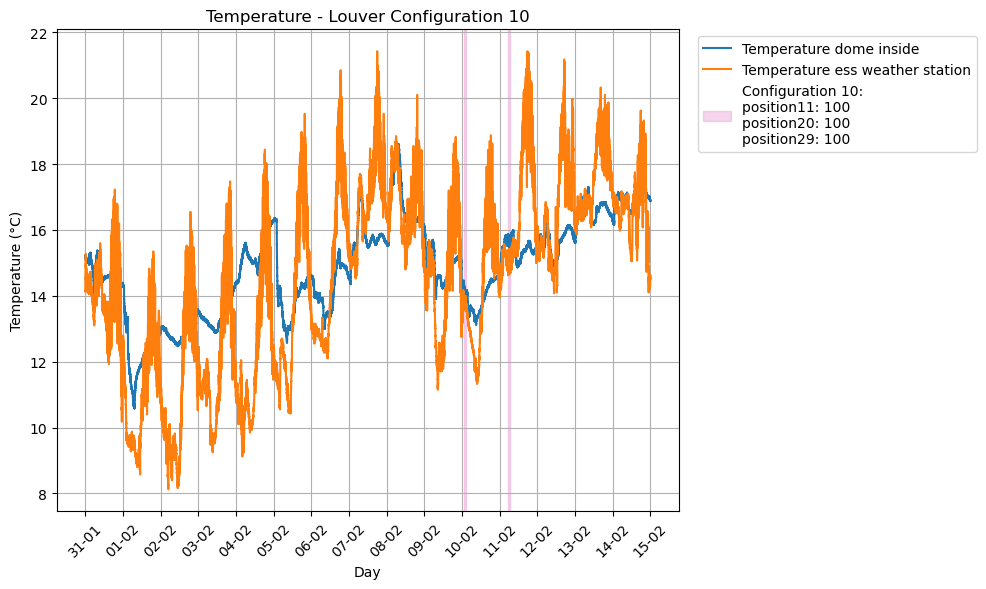

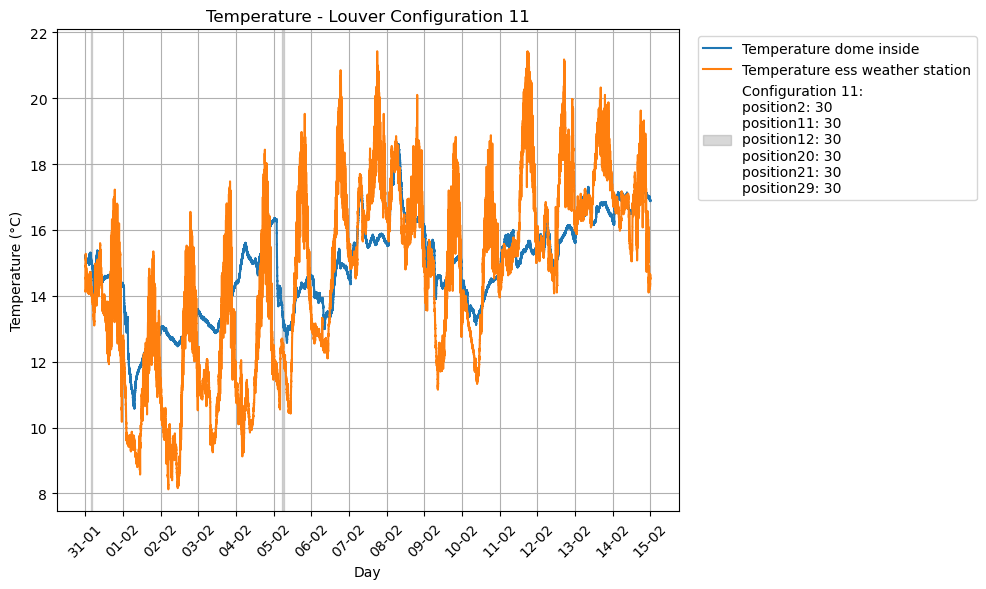

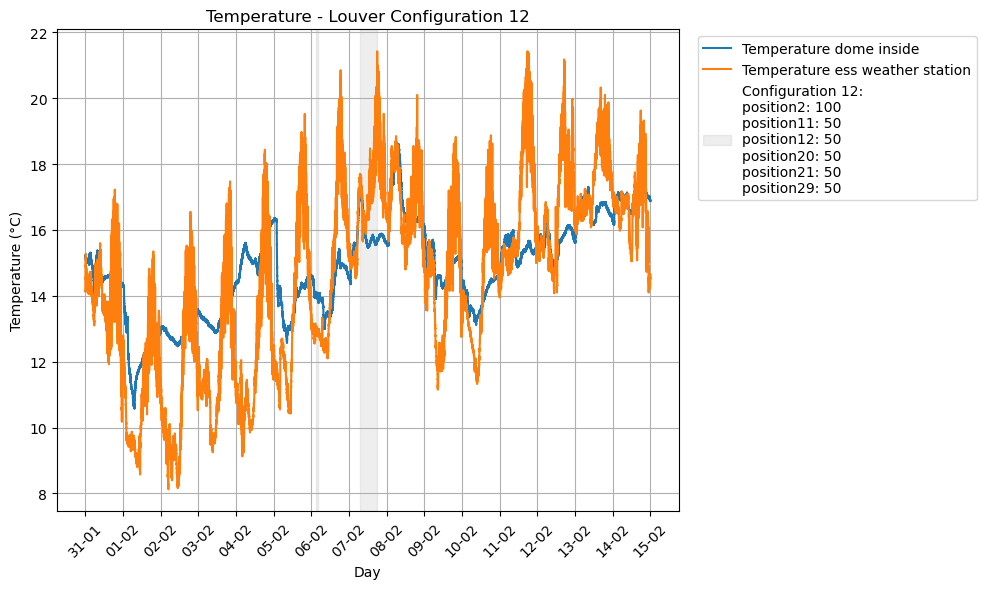

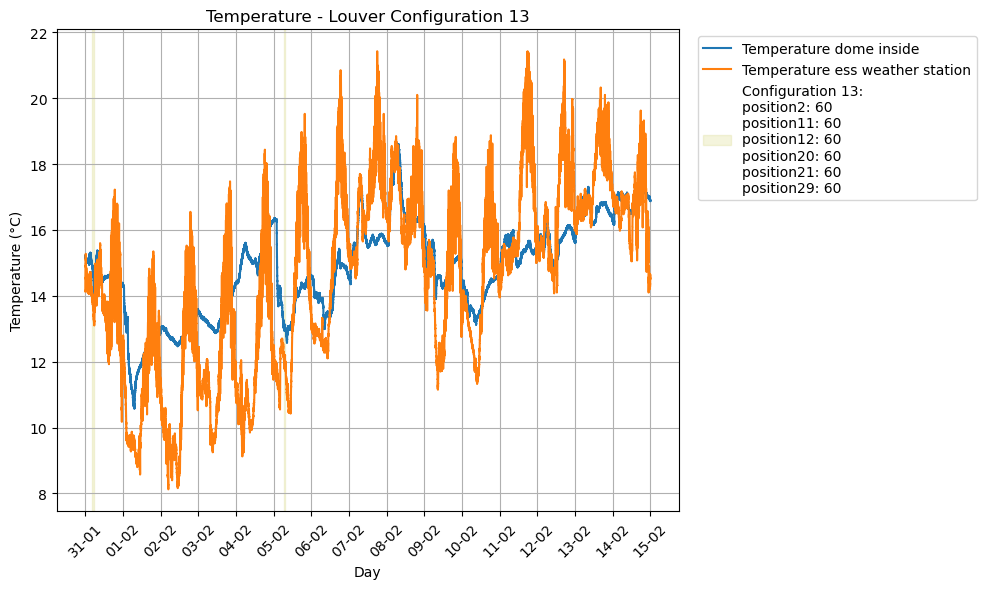

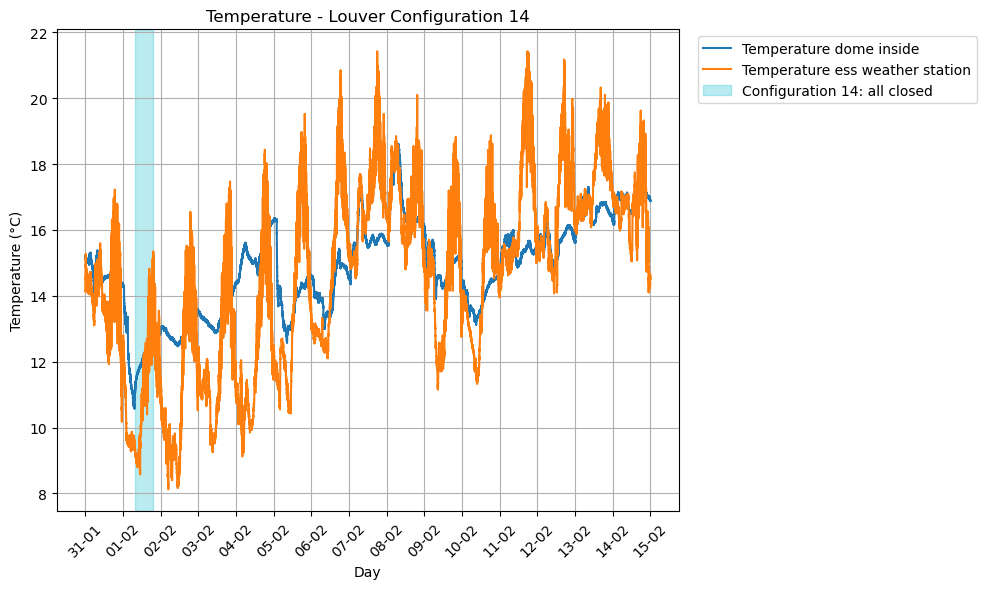

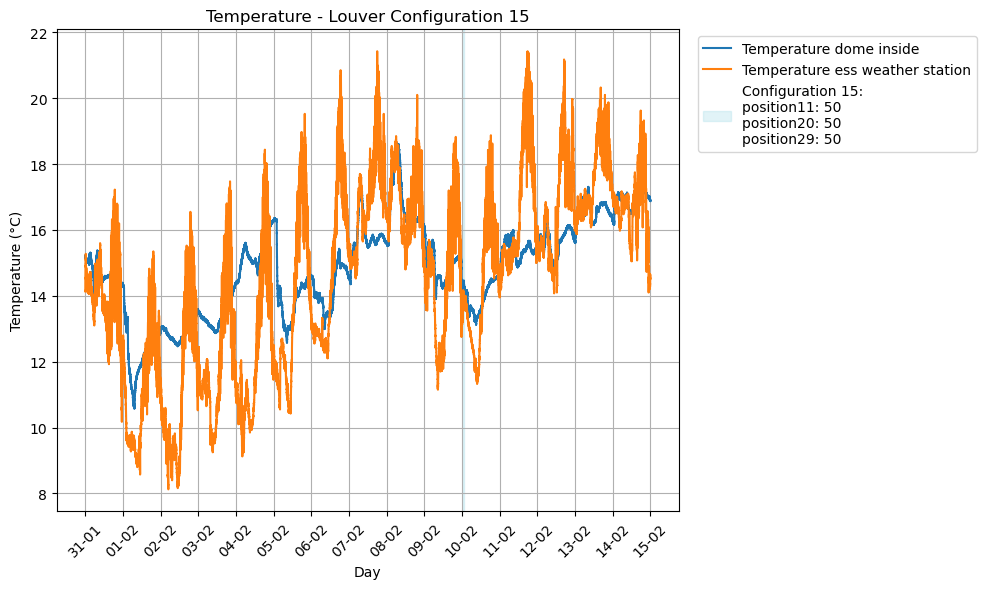

In [30]:
plot_temperature_with_louvers(
    df_temp_inandout, 
    df_setlouvers)

Table: basic statistics per configuration (average, variation)

In [31]:
df_temp_inandout['time'] = pd.to_datetime(df_temp_inandout['time'], utc=True).dt.tz_convert(None)

df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True).dt.tz_convert(None)

df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True).dt.tz_convert(None)

In [ ]:
# NO EJECUTAR
# Format of the times
df_temp_inandout['time'] = pd.to_datetime(df_temp_inandout['time'])
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])
df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'])

In [32]:
df_stats = compute_louvers_stats(df_setlouvers, df_temp_inandout)
df_stats

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,min_temp,max_temp,temp_range,gradient_deg_per_min
0,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:111,62.390887,15.032874,0.096974,14.880000,15.290000,0.410000,-0.005610
1,11,Configuration 11:\nposition2: 30\nposition11: ...,ESS:301,62.390887,14.184949,0.196806,13.875000,14.575000,0.700000,-0.010418
2,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:111,61.528541,14.549212,0.300147,13.800000,14.910000,1.110000,-0.017553
3,13,Configuration 13:\nposition2: 60\nposition11: ...,ESS:301,61.528541,13.628889,0.203313,13.200000,13.950000,0.750000,-0.011783
4,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,1302.698127,14.414911,0.467087,12.250000,15.380000,3.130000,-0.001205
...,...,...,...,...,...,...,...,...,...,...
123,5,Configuration 5:\nposition2: 100\nposition11: ...,ESS:301,62.940816,16.176245,0.084075,15.975000,16.375000,0.400000,-0.000397
124,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,829.880959,16.932793,0.215039,16.490000,17.320000,0.830000,0.000205
125,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,829.880959,16.804807,0.823812,15.050000,19.625000,4.575000,0.002591
126,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:111,300.707535,17.099529,0.112889,16.870001,17.340000,0.469999,-0.001397


In [33]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [34]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,min_temp,max_temp,temp_range,gradient_deg_per_min
4,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,1302.698127,14.414911,0.467087,12.250000,15.380000,3.130000,-0.001205
5,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,1302.698127,13.582436,1.590894,9.500000,17.225000,7.725000,-0.002763
6,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,248.411419,11.309894,0.487439,10.570000,12.260000,1.690001,-0.006602
7,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,248.411419,9.585130,0.107094,9.275000,9.875000,0.600000,-0.000403
22,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,754.525691,13.653100,0.561874,12.580000,14.410000,1.830000,0.001643
23,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,754.525691,14.307737,2.709353,10.425000,19.525000,9.099999,0.006196
32,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,864.180580,13.996189,0.661666,12.990000,15.430000,2.440001,0.001007
33,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,864.180580,14.448052,2.247152,12.100000,20.850000,8.750000,0.007608
36,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,247.765301,15.297693,0.251139,14.350000,15.620000,1.270000,0.004924
37,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,247.765301,15.003694,0.174879,14.525000,15.475000,0.950001,-0.001312


In [35]:
# Summary of the different configuration of louvers
df_summary = (
    df_stats
    .groupby(['louvers_conf','conf_label','sensor'])
    .agg({
        'duration_min':'mean',
        'mean_temp':'mean',
        'std_temp':'mean',
        'gradient_deg_per_min':'mean',
        'temp_range':'mean'
    })
    .reset_index()
)

In [36]:
df_summary

,louvers_conf,conf_label,sensor,duration_min,mean_temp,std_temp,gradient_deg_per_min,temp_range
0,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:111,505.193679,15.074207,0.350591,0.000745,1.362353
1,1,Configuration 1:\nposition2: 100\nposition11: ...,ESS:301,505.193679,14.846620,0.911668,0.000357,3.719118
2,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:111,613.660422,15.173715,0.224653,-0.000333,0.818571
3,2,Configuration 2:\nposition2: 10\nposition11: 1...,ESS:301,613.660422,15.414325,1.396527,-0.006856,5.887500
4,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:111,51.540518,15.641703,0.123200,0.003745,0.462000
5,3,Configuration 3:\nposition2: 50\nposition11: 5...,ESS:301,51.540518,15.097583,0.285641,0.003364,1.092500
6,4,Configuration 4:\nposition11: 100\nposition21:...,ESS:111,24.927925,16.535487,0.036666,0.006969,0.142500
7,4,Configuration 4:\nposition11: 100\nposition21:...,ESS:301,24.927925,16.856777,0.057334,-0.013031,0.253125
8,5,Configuration 5:\nposition2: 100\nposition11: ...,ESS:111,364.782291,15.675729,0.197833,-0.002260,0.810000
9,5,Configuration 5:\nposition2: 100\nposition11: ...,ESS:301,364.782291,16.203434,0.809039,0.001333,2.918750


In [37]:
# plot_mean_temp_per_louver(df_stats, df_setlouvers)

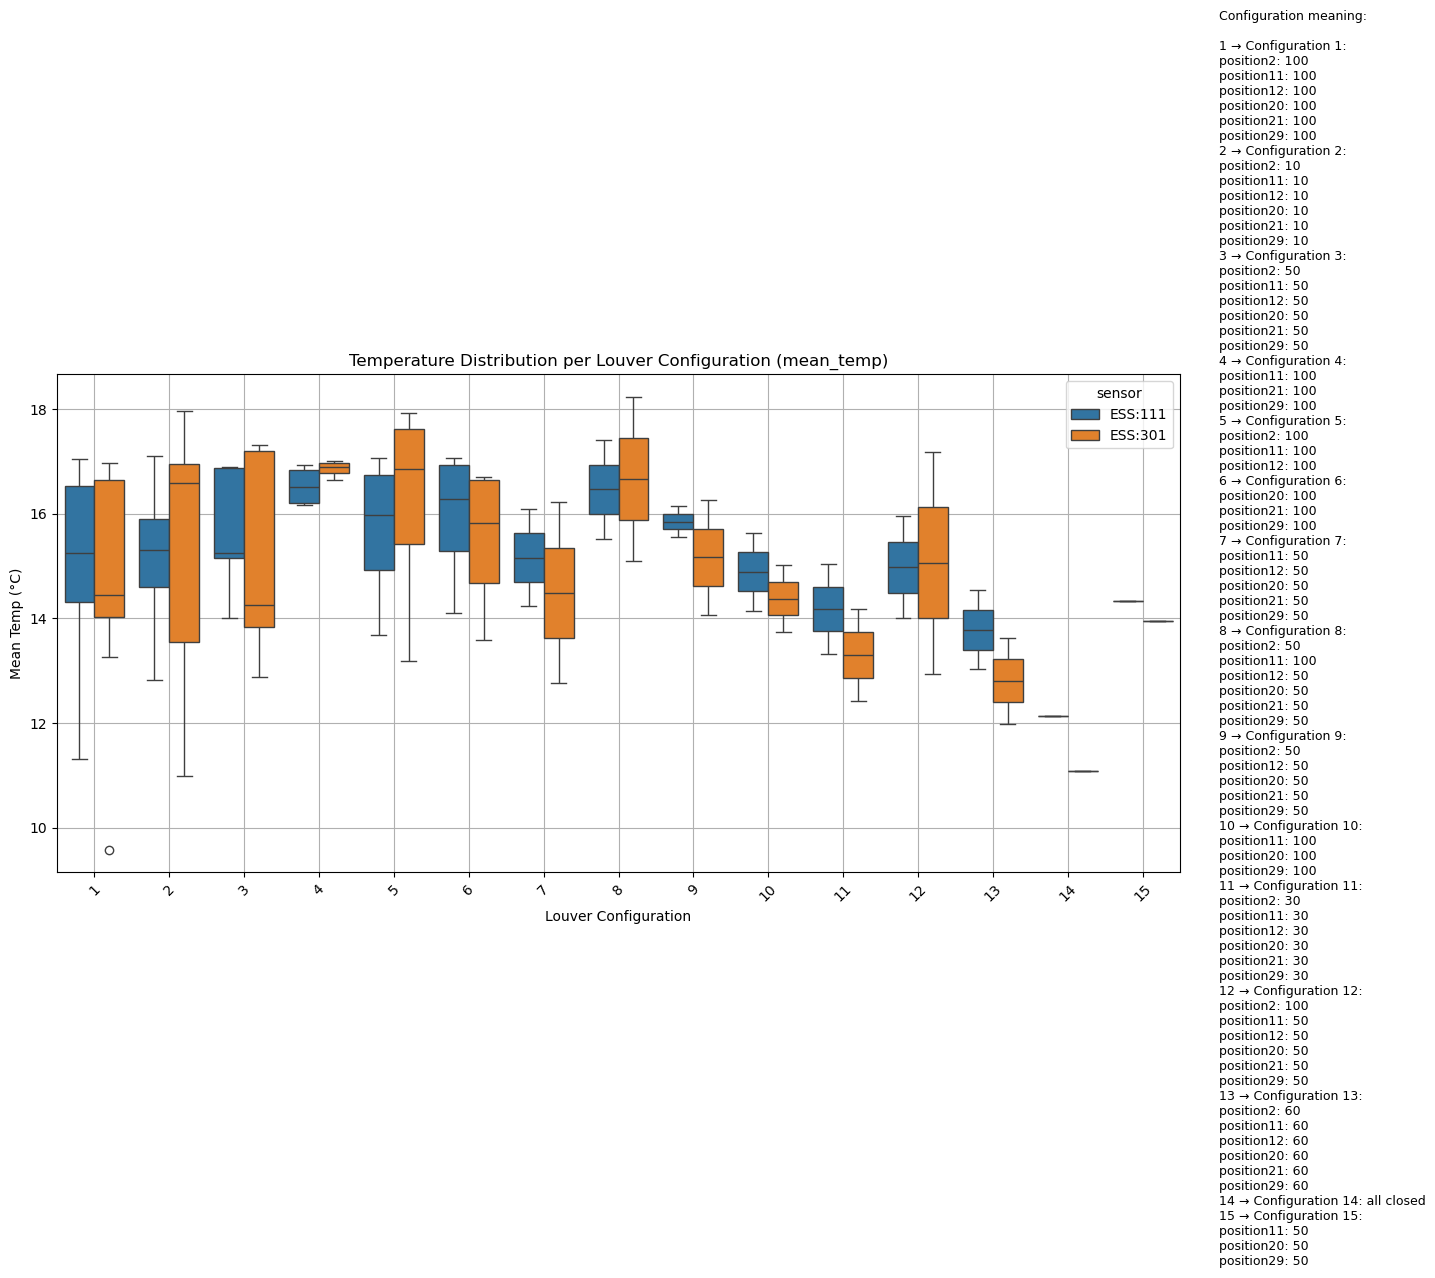

In [38]:
plot_temp_distribution_per_louver(df_stats, df_setlouvers, value_col="mean_temp")

In [39]:
#plot_temp_stability_per_louver(df_stats, df_setlouvers)

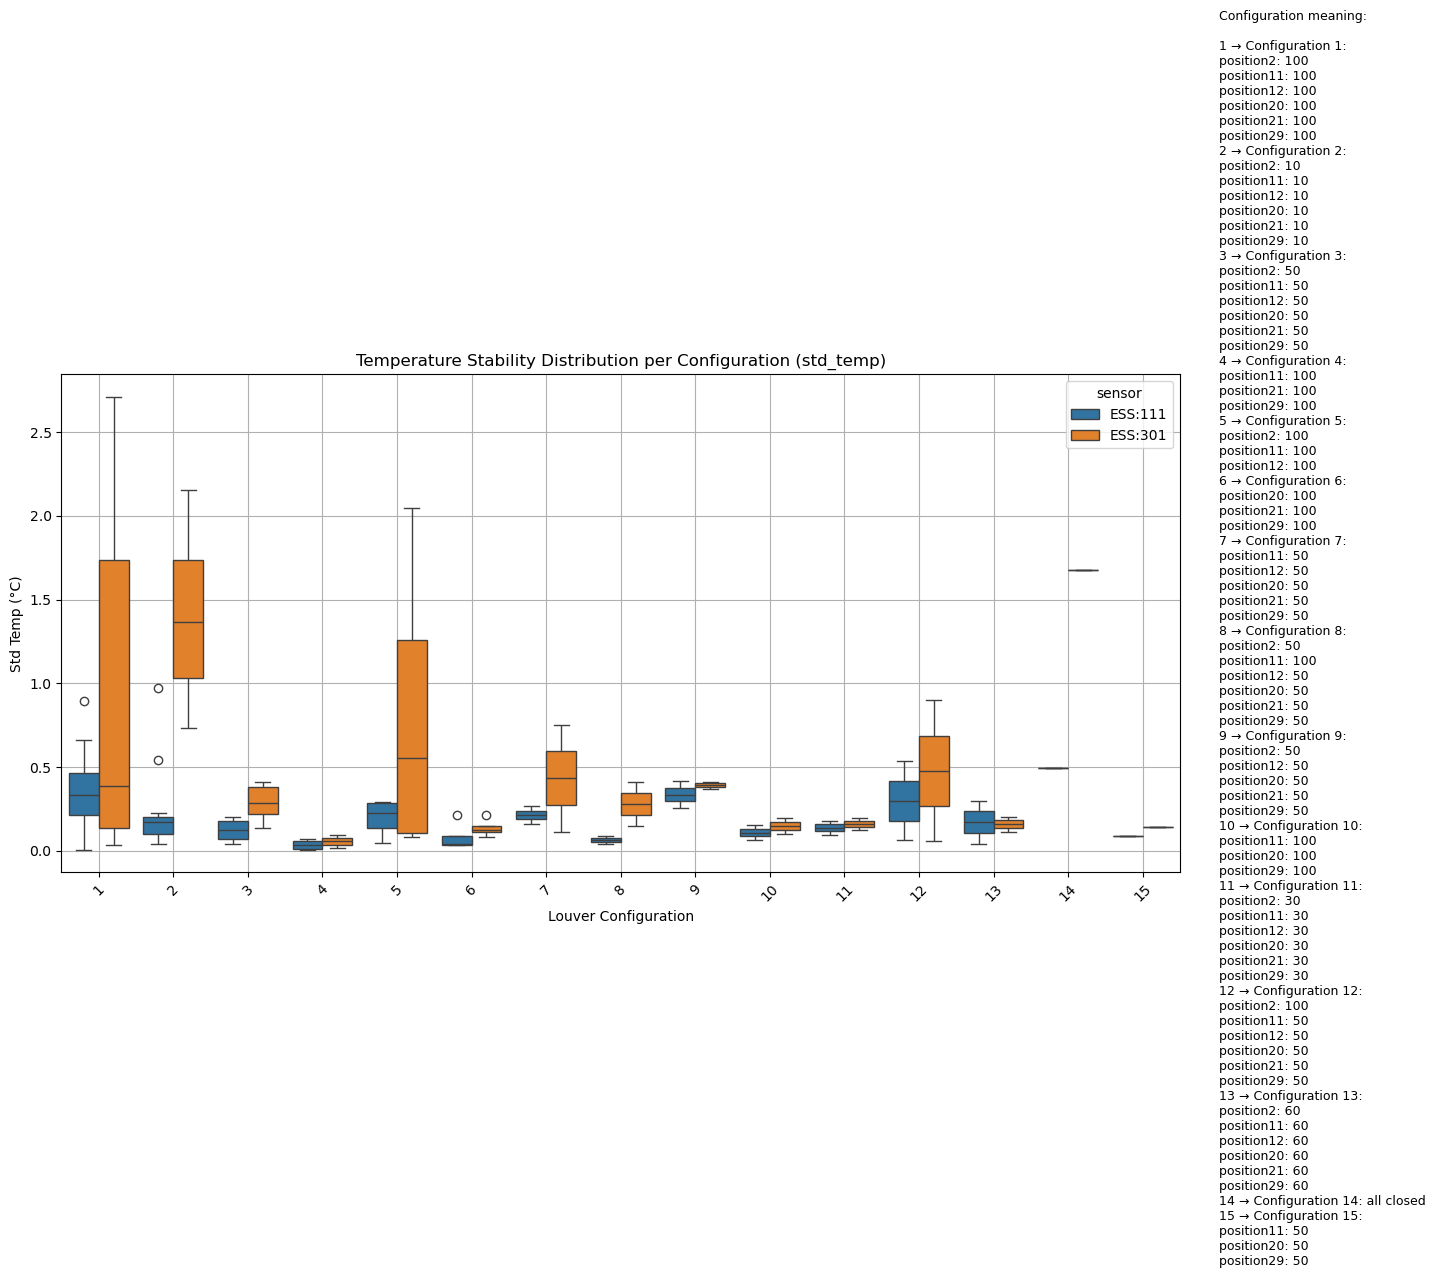

In [40]:
plot_temp_stability_distribution(df_stats, df_setlouvers, value_col="std_temp")

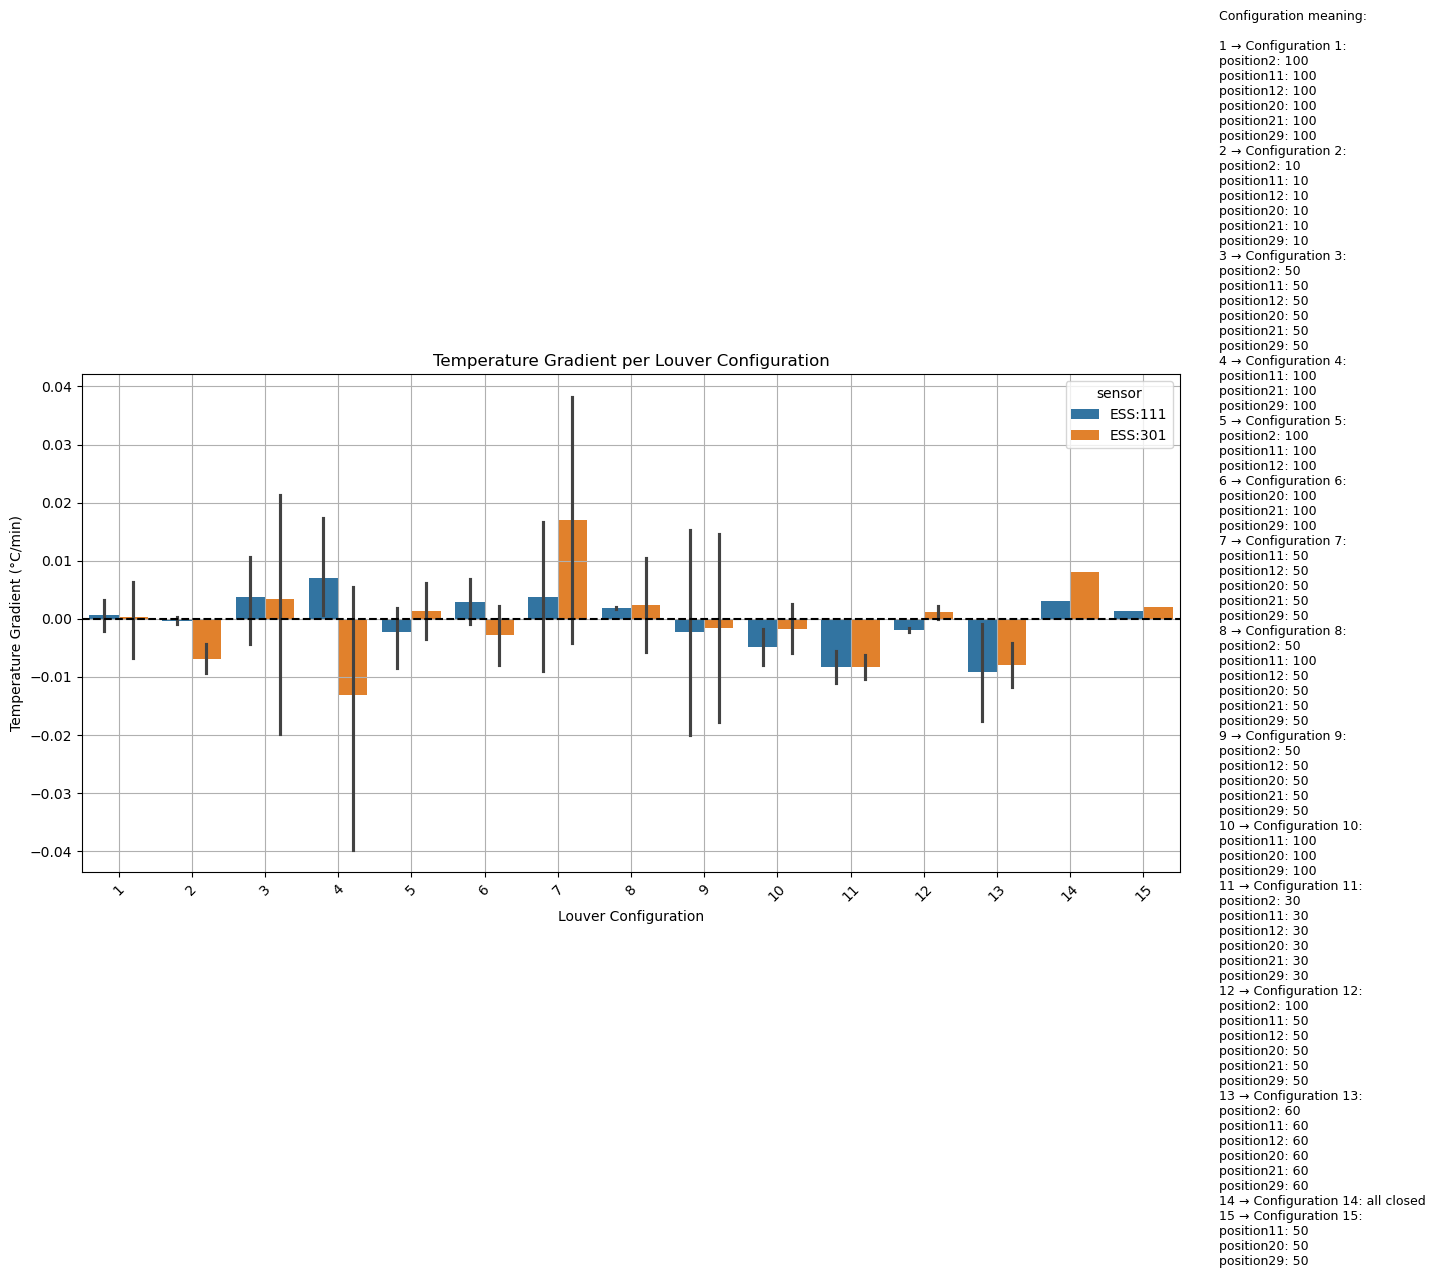

In [41]:
plot_temp_gradient_per_louver(df_stats, df_setlouvers)

# ESS Temperature:  telescope sensors (111-113)

In [ ]:
# Keep only the ESS identities with 111, 112 and 113
df_ess = df_esstemperature[
    df_esstemperature['private_identity'].isin(['ESS:111','ESS:112','ESS:113'])
].copy()

In [ ]:
df_ess.head()

### Plots of telescope sensors (111-113)

In [ ]:
# Make a copy
df_ess = df_ess.copy()

# Convert timestamp to datetime
df_ess['time'] = pd.to_datetime(df_ess['timestamp'], unit='s')

# Sort by time
df_ess = df_ess.sort_values('time')

fig, ax = plt.subplots(figsize=(10,6))

for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# Force one tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Format showing day and month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors")
plt.legend(title="Sensor")
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Cross with the louver settings

In [ ]:
# Make copies to avoid modifying original slices
df_ess = df_ess.copy()
df_setlouvers = df_setlouvers.copy()

# Convert timestamps
df_ess['time'] = pd.to_datetime(df_ess['timestamp'], unit='s')
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])

# Sort data
df_ess = df_ess.sort_values('time')
df_setlouvers = df_setlouvers.sort_values('time_stamp')

fig, ax = plt.subplots(figsize=(10,6))

# Plot temperature lines
for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# Add vertical lines for louver configuration changes
for t in df_setlouvers['time_stamp']:
    ax.axvline(t, linestyle='--', linewidth=1, alpha=0.5)

# One tick per day
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors with Louver Configuration")
plt.legend(title="Sensor")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
df_setlouvers['time_end'] = df_setlouvers['time_stamp'].shift(-1)
max_time = df_ess['time'].max()
df_setlouvers['time_end'] = df_setlouvers['time_end'].fillna(max_time)

In [ ]:
# ESTO SE PODRÏA BORRAR
# Column positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Function to labels
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]

    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"

    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

In [ ]:
# ESTO SE PODRÏA BORRAR


# Colormap for configuration
n_confs = df_setlouvers['louvers_conf'].nunique()
colors = plt.colormaps['tab20'].resampled(n_confs)

df_ess['time'] = pd.to_datetime(df_ess['time'], utc=True)
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'], utc=True)
df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'], utc=True)

df_ess['time'] = df_ess['time'].dt.tz_convert(None)
df_setlouvers['time_stamp'] = df_setlouvers['time_stamp'].dt.tz_convert(None)
df_setlouvers['time_end'] = df_setlouvers['time_end'].dt.tz_convert(None)




fig, ax = plt.subplots(figsize=(12,6))

# --- Temperature Lines ---
for sensor_id, group in df_ess.groupby('private_identity'):
    ax.plot(group['time'], group['temperatureItem0'], label=sensor_id)

# --- Shading by configuration ---
for i, (_, row) in enumerate(df_setlouvers.iterrows()):
    start = row['time_stamp']
    end = row['time_end']
    conf_num = int(row['louvers_conf']) - 1 
    ax.axvspan(start, end, color=colors(conf_num), alpha=0.15)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("ESS Temperature Sensors with Louver Configurations (colored)")
plt.legend(title="Sensor")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Number of unique configuration
conf_ids = sorted(df_setlouvers['louvers_conf'].unique())
n_confs = len(conf_ids)

# Colormap by configuration
colors = plt.get_cmap('tab20', n_confs)

# Columns positions
position_cols = df_setlouvers.filter(regex=r'^position').columns
position_cols = sorted(position_cols, key=lambda x: int(x.replace('position','')))

# Labels for configuration
def build_conf_label(row):
    config = row[position_cols]
    non_zero = config[config != 0]
    if len(non_zero) == 0:
        return f"Configuration {row['louvers_conf']}: all closed"
    lines = [f"Configuration {row['louvers_conf']}:"]
    for col, val in non_zero.items():
        lines.append(f"{col}: {int(val)}")
    return "\n".join(lines)

df_setlouvers['conf_label'] = df_setlouvers.apply(build_conf_label, axis=1)

for conf_num in conf_ids:

    fig, ax = plt.subplots(figsize=(12,6))
    
    for sensor_id, group in df_ess.groupby('private_identity'):
        ax.plot(group['time'], group['temperatureItem0'], label=f"Sensor {sensor_id}")
    
    # A plot for configuration
    conf_df = df_setlouvers[df_setlouvers['louvers_conf'] == conf_num]

    for i, (_, row) in enumerate(conf_df.iterrows()):
        start = row['time_stamp']
        end = row['time_end']
        label = row['conf_label']
        ax.axvspan(start, end, color=colors(int(conf_num)-1), alpha=0.3, label=label)
    
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

    plt.xlabel("Day")
    plt.ylabel("Temperature (°C)")
    plt.title(f"ESS Temperatures - Louver Configuration {conf_num}")
    
    # Avoid duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02,1), loc='upper left')
    
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Table: basic statistics per configuration (average, variation)

In [ ]:
# Format of the times
df_ess['time'] = pd.to_datetime(df_ess['time'])
#df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])
#df_setlouvers['time_end'] = pd.to_datetime(df_setlouvers['time_end'])

In [ ]:
results = []

for _, conf in df_setlouvers.iterrows():

    start = conf['time_stamp']
    end = conf['time_end']
    conf_id = conf['louvers_conf']
    conf_label = conf['conf_label']

    # datos dentro del intervalo
    subset = df_ess[(df_ess['time'] >= start) & (df_ess['time'] <= end)]

    duration = (end - start).total_seconds()/60  # minutos

    for sensor, group in subset.groupby('private_identity'):

        temp = group['temperatureItem0']

        if len(temp) < 2:
            continue

        gradient = (temp.iloc[-1] - temp.iloc[0]) / duration

        results.append({
            "louvers_conf": conf_id,
            "conf_label": conf_label,
            "sensor": sensor,
            "duration_min": duration,
            "mean_temp": temp.mean(),
            "std_temp": temp.std(),
            "min_temp": temp.min(),
            "max_temp": temp.max(),
            "temp_range": temp.max() - temp.min(),
            "gradient_deg_per_min": gradient
        })

df_stats = pd.DataFrame(results)

In [ ]:
df_stats

In [ ]:
# Separate in tables for louvers configuration
tables = {}

for conf in df_stats['louvers_conf'].unique():
    tables[conf] = df_stats[df_stats['louvers_conf']==conf]

In [ ]:
# For example, to see configuration 1 for the 3 sensors and the stat each time this configuration is working
tables[1]

In [ ]:
# Summary of the different configuration of louvers
df_summary = (
    df_stats
    .groupby(['louvers_conf','conf_label','sensor'])
    .agg({
        'duration_min':'mean',
        'mean_temp':'mean',
        'std_temp':'mean',
        'gradient_deg_per_min':'mean',
        'temp_range':'mean'
    })
    .reset_index()
)

In [ ]:
df_summary

In [ ]:
df_stats.columns

In [ ]:
df_stats.head()

In [ ]:
# Mean Temperature per Louver Configuration
# Shows which configuration leads to higher or lower temperatures

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="mean_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Mean Temperature (°C)")
plt.title("Mean Temperature per Louver Configuration")

plt.xticks(rotation=45)
plt.grid(True)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.tight_layout()
plt.show()

In [ ]:
# Temperature Stability per Louver Configuration
# Lower standard deviation means more stable thermal behavior

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="std_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Standard Deviation (°C)")
plt.title("Temperature Stability per Louver Configuration")
plt.xticks(rotation=45)
plt.grid(True)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)


plt.tight_layout()
plt.show()

In [ ]:
# Temperature Gradient per Louver Configuration
# Positive values indicate temperature increase, negative values indicate cooling

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_stats,
    x="louvers_conf",
    y="gradient_deg_per_min",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Gradient (°C/min)")
plt.title("Temperature Gradient per Louver Configuration")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')


# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Temperature Distribution per Louver Configuration
# Shows variability and outliers across repeated occurrences

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_stats,
    x="louvers_conf",
    y="mean_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Mean Temperature (°C)")
plt.title("Temperature Distribution per Louver Configuration")
plt.xticks(rotation=45)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)


plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Temperature Stability Distribution per Configuration
# Compares temperature variability across configurations

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_stats,
    x="louvers_conf",
    y="std_temp",
    hue="sensor"
)

plt.xlabel("Louver Configuration")
plt.ylabel("Temperature Standard Deviation (°C)")
plt.title("Temperature Stability Distribution per Configuration")
plt.xticks(rotation=45)

# ---- Create configuration legend text ----
conf_map = (
    df_setlouvers[['louvers_conf','conf_label']]
    .drop_duplicates()
    .sort_values('louvers_conf')
)

text = "\n".join(
    f"{row.louvers_conf} → {row.conf_label}"
    for _, row in conf_map.iterrows()
)

# ---- Add configuration explanation outside the plot ----
plt.gcf().text(
    1.02,
    0.5,
    "Configuration meaning:\n\n" + text,
    fontsize=9,
    va="center"
)

plt.grid(True)
plt.tight_layout()
plt.show()

####*********** SUCIO*****

In [ ]:
def query_thermal(start, end):
    df_thermal = getEfdData(
        client=efd_client,
        topic="lsst.sal.MTDome.thermal",
        columns=["*"],
        begin=start,
        end=end,
    )

    return df_thermal

In [ ]:
df_thermal = query_thermal(t_start_period, t_end_period)

In [ ]:
df_thermal.head()

In [ ]:
df.columns

In [ ]:
# Make sure time columns are datetime (if not already)
df_setlouvers['time_stamp'] = pd.to_datetime(df_setlouvers['time_stamp'])
df_thermal['timestamp'] = pd.to_datetime(df_thermal['timestamp'])

# Sort both dataframes by time
df_setlouvers = df_setlouvers.sort_values('time_stamp')
df_thermal = df_thermal.sort_values('timestamp')

In [ ]:
# Perform temporal merge
df_thermal_with_conf = pd.merge_asof(
    df_thermal,
    df_setlouvers[['time_stamp', 'louvers_conf']],
    left_on='timestamp',
    right_on='time_stamp',
    direction='backward'  # take last known configuration
)

In [ ]:
def query_weather(start, end):
    df_weather = getEfdData(
        client=efd_client,
        topic="lsst.sal.WeatherForecast.dailyTrend",
        columns=["Max temperature", "temperatureMin", "Mean temperature", ],
        begin=start,
        end=end,
    )

    return df_weather

In [ ]:
df = query_weather(t_start_period, t_end_period)